## ✈ Flight Disruption Impact Predictor ✈

### Core Concept

When a single flight gets disrupted, it can trigger a domino effect across an airline's entire network (delaying flights that rely on the same aircraft or crew).

In this project, we will:
1. Generate a synthetic dataset: representing flight disruption features.
2. Analyze and train a classifier: to predict whether a disruption will have a High Downstream Impact or a Low/Managed Downstream Impact.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(101)
num_disruptions = 500

# Feature 1: Inbound Delay in minutes
inbound_delay_mins = np.random.exponential(scale=45, size=num_disruptions) + 10

# Feature 2: Hub Congestion index (percentage of gates occupied, 0 to 100)
hub_congestion_pct = np.random.uniform(30, 95, size=num_disruptions)

# Feature 3: Crew connection buffer time in minutes (lower buffer = higher risk of cascading delay)
crew_buffer_mins = np.random.uniform(15, 120, size=num_disruptions)

# Downstream Impact score calculation
# High inbound delay, high congestion, and tight crew buffers lead to high downstream impact
impact_score = (
    (inbound_delay_mins > 60).astype(int) * 3.5 +
    (hub_congestion_pct > 80).astype(int) * 2.5 -
    (crew_buffer_mins > 45).astype(int) * 2.0
)

# Add noise to mimic real-world unpredictability
noise = np.random.normal(0, 1.0, size=num_disruptions)
total_impact_score = impact_score + noise

# Binary target: 1 = High Downstream Impact (network cascade), 0 = Managed Impact
is_high_impact = (total_impact_score > 1.5).astype(int)

# Construct the DataFrame
df_disruption = pd.DataFrame({
    'disruption_id': [f"DIS_{i+1}" for i in range(num_disruptions)],
    'inbound_delay_mins': np.round(inbound_delay_mins, 1),
    'hub_congestion_pct': np.round(hub_congestion_pct, 1),
    'crew_buffer_mins': np.round(crew_buffer_mins, 1),
    'high_downstream_impact': is_high_impact
})

print("Synthetic disruption dataset created successfully!")
print(df_disruption['high_downstream_impact'].value_counts(normalize=True))
display(df_disruption.head())

Synthetic disruption dataset created successfully!
high_downstream_impact
0    0.712
1    0.288
Name: proportion, dtype: float64


,disruption_id,inbound_delay_mins,hub_congestion_pct,crew_buffer_mins,high_downstream_impact
0,DIS_1,42.7,71.2,95.6,0
1,DIS_2,48.0,52.7,113.4,0
2,DIS_3,11.3,66.3,57.5,0
3,DIS_4,18.5,82.4,45.2,0
4,DIS_5,62.0,92.1,118.3,1


### Feature Correlation Analysis
We will now calculate and plot the correlation matrix to see how the factors relate to each other and to our target outcome, which is `high_downstream_impact`.

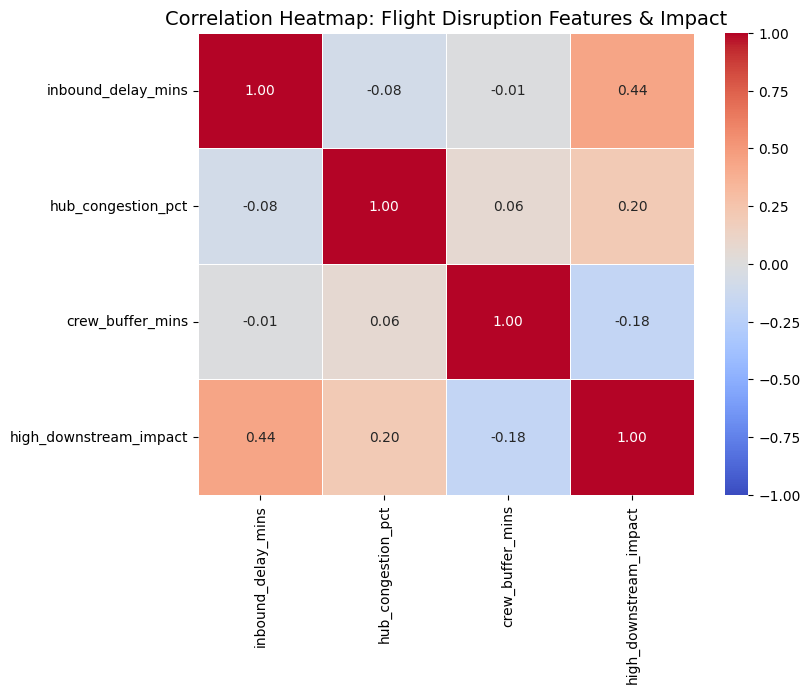

In [ ]:
# Calculate the correlation matrix
corr_matrix = df_disruption[['inbound_delay_mins', 'hub_congestion_pct', 'crew_buffer_mins', 'high_downstream_impact']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap: Flight Disruption Features & Impact', fontsize=14)
plt.show()

### Data Splitting for Training and Testing

We will separate the predictive features from our binary target variable `high_downstream_impact` and split the data into training (80%) and testing (20%) sets to ensure we can evaluate our model accurately.

In [ ]:
# Define independent features (X) and target variable (y)
features = ['inbound_delay_mins', 'hub_congestion_pct', 'crew_buffer_mins']
X = df_disruption[features]
y = df_disruption['high_downstream_impact']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape : {X_test.shape}")

Training set shape: (400, 3)
Testing set shape : (100, 3)


### Build and Evaluate the Predictive Model

We will fit a machine learning model Random Forest Classifier to learn the rules that connect initial disruptions to severe downstream cascades, then test its predictive capabilities.

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        71
           1       0.64      0.72      0.68        29

    accuracy                           0.80       100
   macro avg       0.76      0.78      0.77       100
weighted avg       0.81      0.80      0.80       100



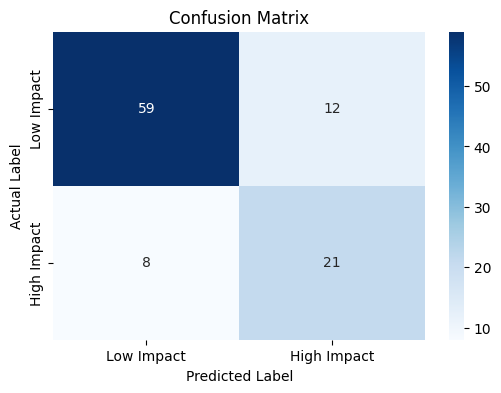

In [ ]:
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=101, max_depth=5)

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Impact', 'High Impact'], yticklabels=['Low Impact', 'High Impact'])
plt.title('Confusion Matrix', fontsize=12)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Live Operational Impact Assessor

Now let's simulate a real-time system used by airline operations controllers to proactively gauge whether an arriving delayed flight will trigger severe downstream schedule delays.

In [ ]:
def predict_disruption_impact(inbound_delay, hub_congestion, crew_buffer):
    """
    Predicts whether an incoming flight disruption will cause a high downstream impact.

    Parameters:
    inbound_delay (float): Incoming flight delay in minutes
    hub_congestion (float): Occupied gate capacity percentage (0 - 100)
    crew_buffer (float): Crew connection time buffer in minutes
    """
    # Create input DataFrame
    input_data = pd.DataFrame([[inbound_delay, hub_congestion, crew_buffer]],
                              columns=['inbound_delay_mins', 'hub_congestion_pct', 'crew_buffer_mins'])

    # Predict probability of high downstream impact
    probability = model.predict_proba(input_data)[0][1]
    prediction = model.predict(input_data)[0]

    print("--- LIVE OPERATIONS DISRUPTION ASSESSMENT ---")
    print(f"Inbound Delay        : {inbound_delay} mins")
    print(f"Hub Gate Congestion  : {hub_congestion}%")
    print(f"Crew Connection Buffer: {crew_buffer} mins")
    print(f"Cascading Delay Risk  : {probability * 100:.1f}%")

    if prediction == 1:
        print("🚨 ALERT: High Risk of Downstream Disruption! Suggest swapping backup crew or gate reassignment.")
    else:
        print("✅ STABLE: Disruption risk is within manageable thresholds.")

# Test Scenario 1: Heavy inbound delay and low crew buffer (High Risk)
predict_disruption_impact(inbound_delay=95.0, hub_congestion=85.0, crew_buffer=20.0)

# Test Scenario 2: Small inbound delay and healthy crew buffer (Low Risk)
print()
predict_disruption_impact(inbound_delay=20.0, hub_congestion=45.0, crew_buffer=90.0)

--- LIVE OPERATIONS DISRUPTION ASSESSMENT ---
Inbound Delay        : 95.0 mins
Hub Gate Congestion  : 85.0%
Crew Connection Buffer: 20.0 mins
Cascading Delay Risk  : 96.7%
🚨 ALERT: High Risk of Downstream Disruption! Suggest swapping backup crew or gate reassignment.

--- LIVE OPERATIONS DISRUPTION ASSESSMENT ---
Inbound Delay        : 20.0 mins
Hub Gate Congestion  : 45.0%
Crew Connection Buffer: 90.0 mins
Cascading Delay Risk  : 2.7%
✅ STABLE: Disruption risk is within manageable thresholds.
